In [38]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [39]:
train_data = pd.read_csv('/Users/adityagarg/Documents/11th Grade/(H) Data Analytics/Unit_6_Project/training_data.csv')
train_data.head()

,Categorical_Sepal_Length_Feature1,Categorical_Petal_Length_Feature2,Categorical_Petal_Width_Feature3,Type_of_Flower_Target,Random_Assigned_Number
0,Large_Sepal_Length,Medium_Petal_Length,Medium_Petal_Width,Iris-versicolor,0.001177
1,Medium_Sepal_Length,Medium_Petal_Length,Small_Petal_Width,Iris-versicolor,0.004767
2,Medium_Sepal_Length,Large_Petal_Length,Large_Petal_Width,Iris-virginica,0.005255
3,Medium_Sepal_Length,Medium_Petal_Length,Medium_Petal_Width,Iris-versicolor,0.008004
4,Medium_Sepal_Length,Medium_Petal_Length,Medium_Petal_Width,Iris-versicolor,0.025458


In [40]:
test_data = pd.read_csv('/Users/adityagarg/Documents/11th Grade/(H) Data Analytics/Unit_6_Project/test_data.csv')
test_data.head()

,Categorical_Sepal_Length_Feature1,Categorical_Petal_Length_Feature2,Categorical_Petal_Width_Feature3,Type_of_Flower_Target,Random_Assigned_Number
0,Small_Sepal_Length,Small_Petal_Length,Small_Petal_Width,Iris-setosa,0.646503
1,Large_Sepal_Length,Large_Petal_Length,Large_Petal_Width,Iris-virginica,0.666532
2,Medium_Sepal_Length,Medium_Petal_Length,Medium_Petal_Width,Iris-versicolor,0.669348
3,Medium_Sepal_Length,Medium_Petal_Length,Medium_Petal_Width,Iris-virginica,0.672958
4,Medium_Sepal_Length,Medium_Petal_Length,Medium_Petal_Width,Iris-versicolor,0.677911


In [41]:
train_data['Type_of_Flower_Target'].value_counts(normalize=False)

Type_of_Flower_Target
Iris-versicolor    34
Iris-virginica     34
Iris-setosa        22
Name: count, dtype: int64

In [42]:
X = train_data[['Categorical_Sepal_Length_Feature1', 'Categorical_Petal_Length_Feature2', 'Categorical_Petal_Width_Feature3']]
Y = train_data['Type_of_Flower_Target']

In [43]:
X_train_encoded = pd.get_dummies(X, columns=['Categorical_Sepal_Length_Feature1', 'Categorical_Petal_Length_Feature2', 'Categorical_Petal_Width_Feature3'])
y_train = train_data['Type_of_Flower_Target']

X_test = test_data[['Categorical_Sepal_Length_Feature1', 'Categorical_Petal_Length_Feature2', 'Categorical_Petal_Width_Feature3']]
y_test = test_data['Type_of_Flower_Target']
X_test_encoded = pd.get_dummies(X_test, columns=['Categorical_Sepal_Length_Feature1', 'Categorical_Petal_Length_Feature2', 'Categorical_Petal_Width_Feature3'])

print(f"Training set size: {len(X_train_encoded)}")
print(f"Testing set size: {len(X_test_encoded)}")

Training set size: 90
Testing set size: 60


In [44]:
model1 = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)
model1.fit(X_train_encoded, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)

In [45]:
model1 = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)
model1.fit(X_train_encoded, y_train)
y_pred1 = model1.predict(X_test_encoded)
accuracy1 = accuracy_score(y_test, y_pred1)
print(f"Model 1 accuracy: {accuracy1}")

Model 1 accuracy: 0.9166666666666666


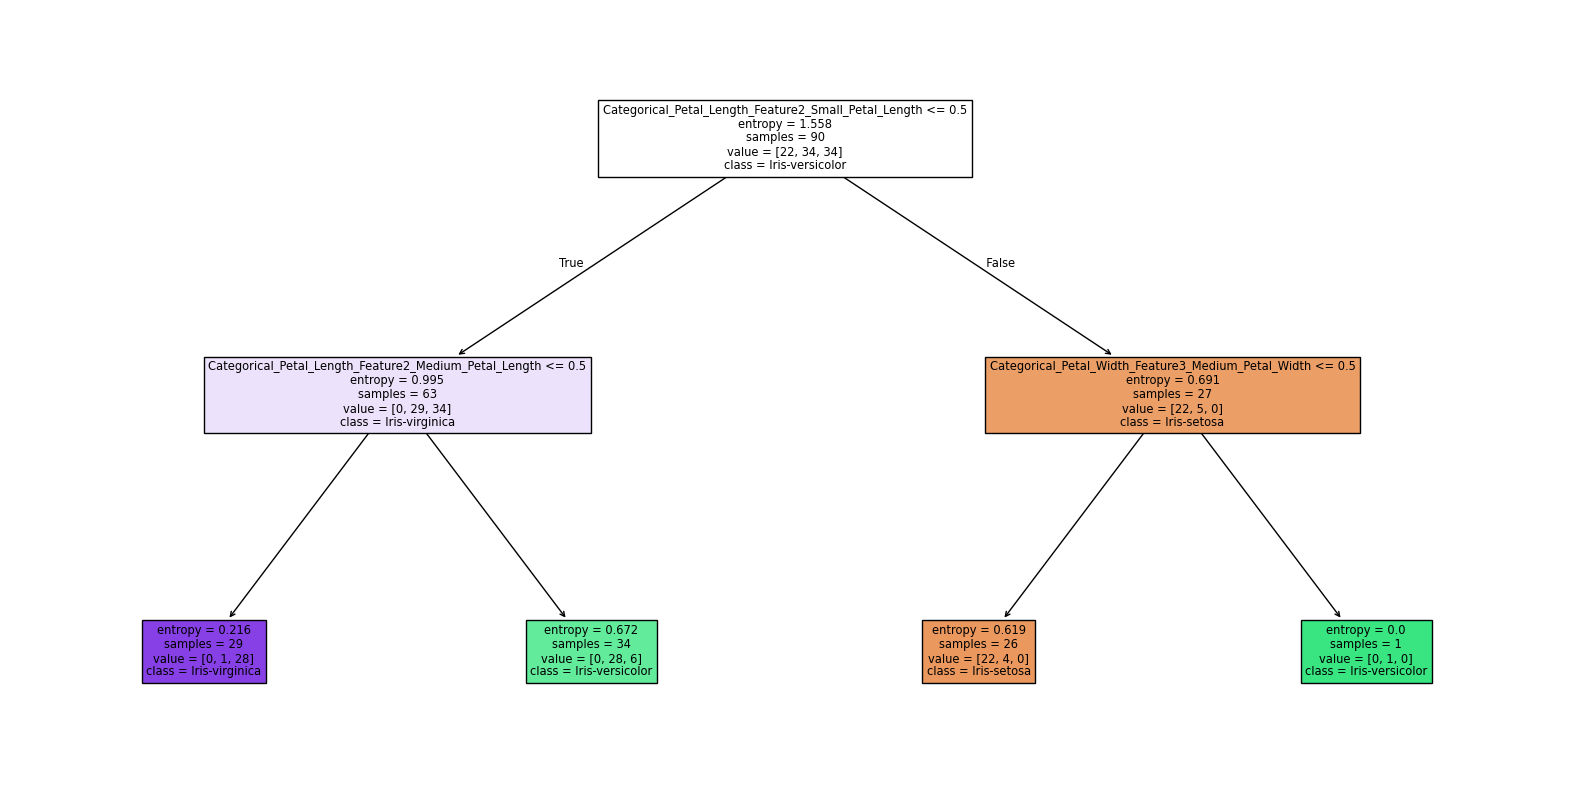

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model1, filled=True, feature_names=X_train_encoded.columns, class_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
plt.show()